# DBSCAN Method of clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Given points
X = np.array([
    [3,7],   # p1
    [1,6],   # p2
    [5,5],   # p3
    [6,4],   # p4
    [7,3],   # p5
    [6,2],   # p6
    [7,2],   # p7
    [8,4],   # p8
    [3,3],   # p9
    [2,6],   # p10
    [3,5],   # p11
    [2,4]    # p12
])

# Apply DBSCAN
dbscan = DBSCAN(
    eps=1.9,        # radius of cluster
    min_samples=4,  # minimum points in cluster
    metric='euclidean'
)

labels = dbscan.fit_predict(X)



P1 -> Cluster 1
P2 -> Cluster 1
P3 -> Cluster -1
P4 -> Cluster 0
P5 -> Cluster 0
P6 -> Cluster 0
P7 -> Cluster 0
P8 -> Cluster 0
P9 -> Cluster -1
P10 -> Cluster 1
P11 -> Cluster 1
P12 -> Cluster -1


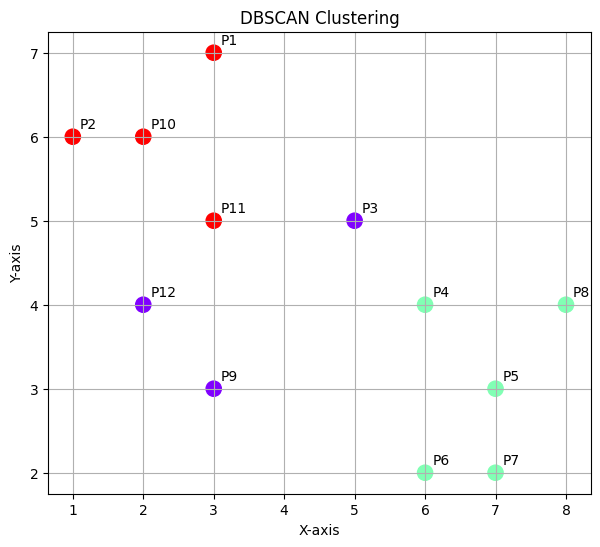

In [2]:
# Print cluster labels
for i, label in enumerate(labels):
    print(f"P{i+1} -> Cluster {label}")

# Plotting
plt.figure(figsize=(7,6))

scatter = plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='rainbow',
    s=120
)

# Annotate points
for i, point in enumerate(X):
    plt.text(point[0]+0.1, point[1]+0.1, f"P{i+1}")

plt.title("DBSCAN Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)

plt.show()

# Clustering on wine dataset

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns


In [4]:
### BEGIN SOLUTION
# Import the data
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/Wine_Quality_Data.csv")

data.head(4).T

,0,1,2,3
fixed_acidity,7.4,7.8,7.8,11.2
volatile_acidity,0.7,0.88,0.76,0.28
citric_acid,0.0,0.0,0.04,0.56
residual_sugar,1.9,2.6,2.3,1.9
chlorides,0.076,0.098,0.092,0.075
free_sulfur_dioxide,11.0,25.0,15.0,17.0
total_sulfur_dioxide,34.0,67.0,54.0,60.0
density,0.9978,0.9968,0.997,0.998
pH,3.51,3.2,3.26,3.16
sulphates,0.56,0.68,0.65,0.58


## Question 1

*   Import the data and examine the features.
*   Note which are continuous, categorical, and boolean.
*   How many entries are there for the two colors and range of qualities?
*   Make a histogram plot of the quality for each of the wine colors.


In [6]:
data.shape

(6497, 13)

In [8]:
data.dtypes


fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
color                    object
dtype: object

In [9]:
data.color.value_counts()

color
white    4898
red      1599
Name: count, dtype: int64

In [10]:
data.color.value_counts(normalize= True)

color
white    0.753886
red      0.246114
Name: proportion, dtype: float64

In [11]:
data.quality.value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

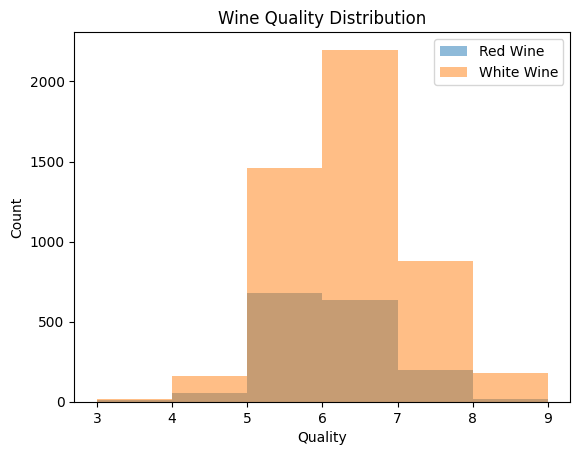

In [15]:
# bins
bins = [3,4,5,6,7,8,9]

# red wine quality
red_quality = data[data['color']=='red']['quality']

# white wine quality
white_quality = data[data['color']=='white']['quality']

# histogram
plt.hist(red_quality, bins=bins, alpha=0.5, label='Red Wine')
plt.hist(white_quality, bins=bins, alpha=0.5, label='White Wine')

# labels
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Wine Quality Distribution')

# legend
plt.legend()

plt.show()

## Question 2

*   Examine the correlation and skew of the relevant variables--everything except color and quality (without dropping these columns from our data).
*   Perform any appropriate feature transformations and/or scaling.
*   Examine the pairwise distribution of the variables with pairplots to verify scaling and normalization efforts.


In [16]:
# numerical columns
float_columns = [col for col in data.columns 
                 if col not in ['color', 'quality']]

# correlation matrix
corr_mat = data[float_columns].corr()

# make diagonal values 0
for i in range(len(float_columns)):
    corr_mat.iloc[i, i] = 0

# display
corr_mat

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
fixed_acidity,0.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452
volatile_acidity,0.219008,0.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640
citric_acid,0.324436,-0.377981,0.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493
residual_sugar,-0.111981,-0.196011,0.142451,0.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415
chlorides,0.298195,0.377124,0.038998,-0.128940,0.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916
free_sulfur_dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,0.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838
total_sulfur_dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,0.000000,0.032395,-0.238413,-0.275727,-0.265740
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,0.000000,0.011686,0.259478,-0.686745
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,0.000000,0.192123,0.121248
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,0.000000,-0.003029


In [17]:
# Pairwise maximal correlations
corr_mat.abs().idxmax()

fixed_acidity                        density
volatile_acidity        total_sulfur_dioxide
citric_acid                 volatile_acidity
residual_sugar                       density
chlorides                          sulphates
free_sulfur_dioxide     total_sulfur_dioxide
total_sulfur_dioxide     free_sulfur_dioxide
density                              alcohol
pH                               citric_acid
sulphates                          chlorides
alcohol                              density
dtype: object

In [18]:
skew_columns = (data[float_columns]
                .skew()
                .sort_values(ascending=False))

skew_columns = skew_columns.loc[skew_columns > 0.75]
skew_columns

chlorides              5.399828
sulphates              1.797270
fixed_acidity          1.723290
volatile_acidity       1.495097
residual_sugar         1.435404
free_sulfur_dioxide    1.220066
dtype: float64

In [19]:
# Perform log transform on skewed columns
for col in skew_columns.index.tolist():
    data[col] = np.log1p(data[col])
    
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
data[float_columns] = sc.fit_transform(data[float_columns])

data.head(4)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,0.229509,2.135767,-2.192833,-0.815173,0.624554,-1.193601,-1.446359,1.034993,1.813090,0.250355,-0.915464,5,red
1,0.550261,3.012817,-2.192833,-0.498175,1.281999,-0.013944,-0.862469,0.701486,-0.115073,1.059213,-0.580068,5,red
2,0.550261,2.438032,-1.917553,-0.625740,1.104012,-0.754684,-1.092486,0.768188,0.258120,0.862549,-0.580068,5,red
3,2.802728,-0.337109,1.661085,-0.815173,0.594352,-0.574982,-0.986324,1.101694,-0.363868,0.389396,-0.580068,6,red


KeyboardInterrupt: 

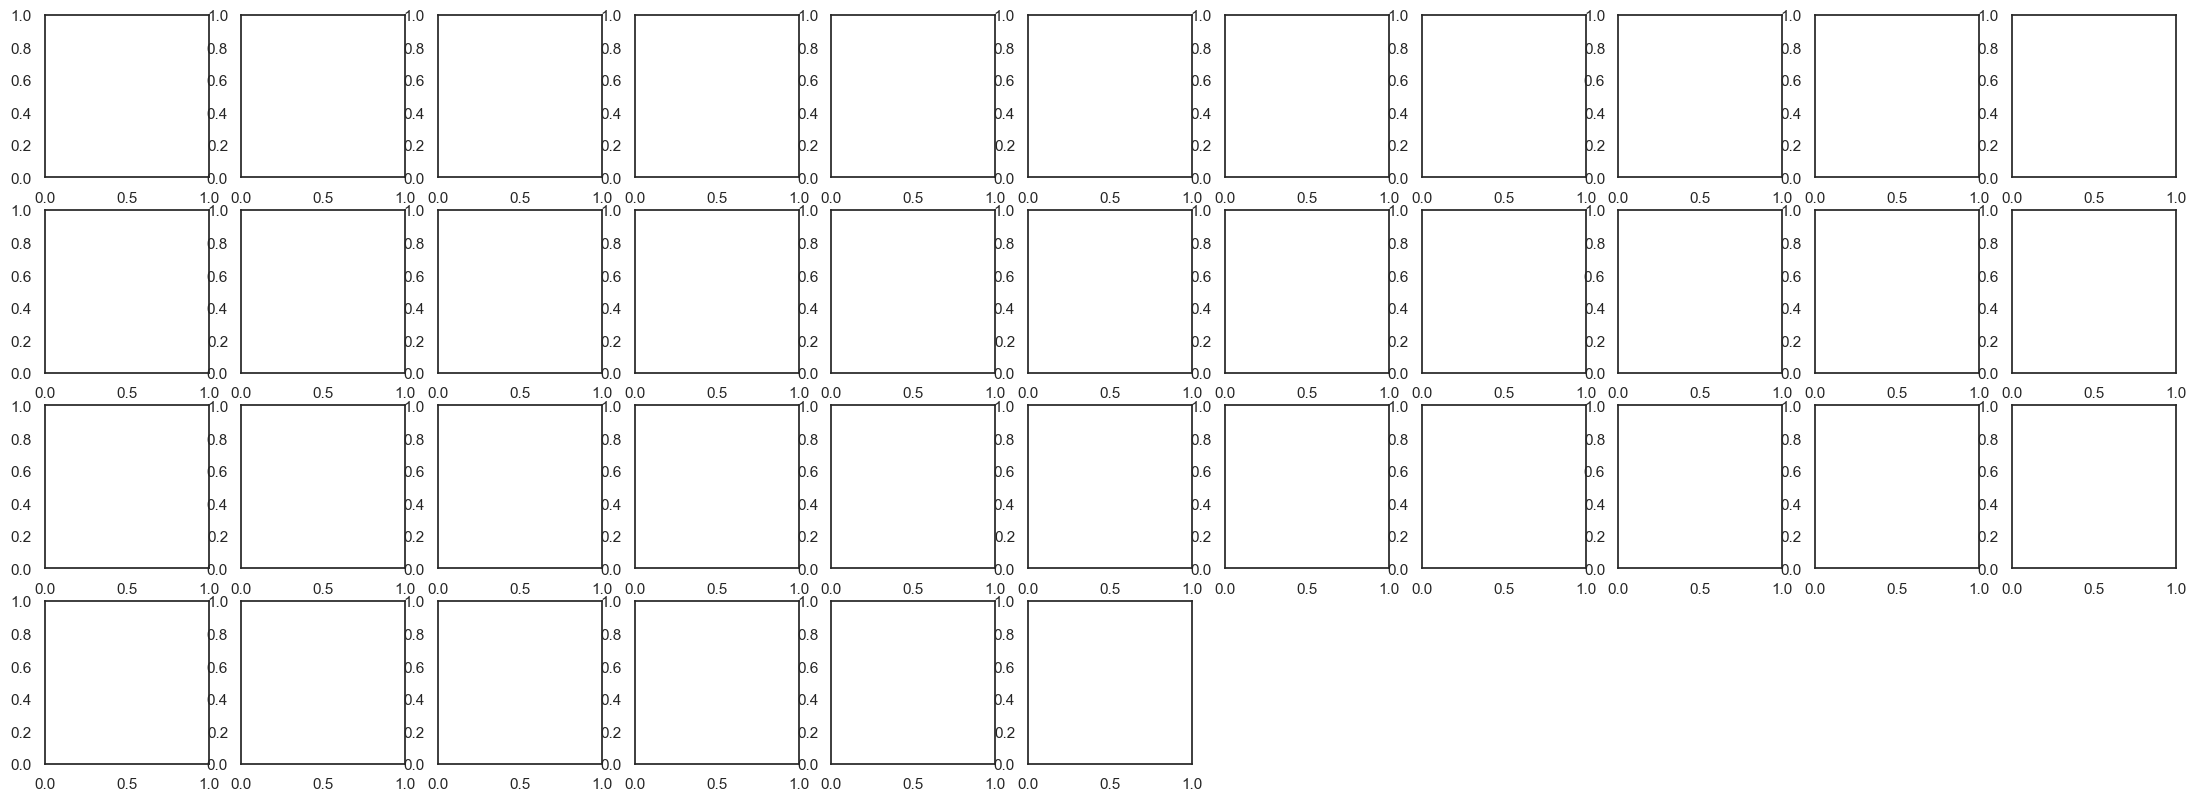

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# style
sns.set_style("white")

# pairplot
sns.pairplot(
    data[float_columns + ['color']],
    hue='color'
)

plt.show()